# Homework Sessions 1-3 - Part A
**MILK10k**

Everything is imported from this repository (`common/` and `src/`), so the
notebook only contains the exercises themselves. The data folder is configured in
one place, `common/config.py` (override it with the `MILK10K_DIR` environment
variable) - no absolute paths.

In [1]:
import sys, os, io, json, time, warnings
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "common").is_dir())
sys.path.insert(0, str(ROOT))   # so `common` and `src` can be imported from any folder

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

from common import config, viz
from common.milk10k import load_metadata

pd.set_option("display.width", 120)
warnings.filterwarnings("ignore", category=UserWarning)

df = load_metadata()                       # per image, plus the dx11 column
gt = pd.read_csv(config.GT_PATH)           # per lesion, one-hot
print("images:", df.shape, "| lesions:", gt.shape, "| data:", config.DATA_DIR)
df.head(3)

images: (10480, 18) | lesions: (5240, 12) | data: /Users/mac/Desktop/ComputerVisionandSpeechRecognition/Session1/milk10k


,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex,dx11
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male,SCCKA
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female,NV
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female,NV


## A1.1 Cross-check the two label files

`metadata.csv` (one row per image) and `training_gt.csv` (one row per lesion)
must describe the same lesions. The checks live in `src/quality.py` so the
pipeline can rerun them.

In [2]:
from src.quality import check_label_files

checks = check_label_files(df, gt)

# (a) same lesions in both files
assert not checks["only_in_metadata"] and not checks["only_in_gt"]
print("(a) lesion_id sets identical:", True)

# (b) exactly one positive class per lesion
assert not checks["bad_one_hot"]
print("(b) every lesion has exactly one positive class:", True)

# (c) does each of the 11 classes map to exactly ONE diagnosis_1?
mapping = checks["class_mapping"]
print("\n(c) class -> diagnosis_1 (lesion counts):")
display(mapping.pivot(index="dx", columns="diagnosis_1", values="lesions").fillna(0).astype(int))
print("classes mapping to MORE than one diagnosis_1:", checks["ambiguous_classes"] or "none")

# (d) the diagnosis hierarchy: each child has exactly one parent
for key in [k for k in checks if "with_many" in k]:
    print(f"\n(d) {key}: {checks[key] or 'none'}")

# (e) the two images of a lesion agree on the lesion-level fields
print("\n(e) lesions whose two images disagree:",
      len(checks["lesions_with_disagreeing_fields"]))

(a) lesion_id sets identical: True
(b) every lesion has exactly one positive class: True

(c) class -> diagnosis_1 (lesion counts):


diagnosis_1,Benign,Indeterminate,Malignant
dx,,,
AKIEC,0,123,180
BCC,0,0,2522
BEN_OTH,44,0,0
BKL,544,0,0
DF,52,0,0
INF,50,0,0
MAL_OTH,0,0,9
MEL,0,0,450
NV,746,0,0


classes mapping to MORE than one diagnosis_1: ['AKIEC']

(d) diagnosis_3_with_many_diagnosis_2: none

(d) diagnosis_2_with_many_diagnosis_1: none

(e) lesions whose two images disagree: 0


**Answer.** In (c) most of the 11 classes sit under exactly one `diagnosis_1`
value, but the mapping is not guaranteed to be clean: any class listed as
ambiguous above appears under more than one `diagnosis_1`. That matters for the
label strategy, because it decides whether `diagnosis_1` can simply be *derived*
from an 11-class prediction. Where the mapping is one-to-one it can (predict the
11-class label, then look up its parent), and where it is not, the 3-class target
has to be trained or decided separately - so I keep `diagnosis_1` as its own
target and treat the 11-class scheme as the stretch goal.

On any new medical dataset I would repeat all of these, but (b) and (e) first:
they are cheap and they catch the errors that silently corrupt training. The most
dangerous failure is (e) - two images of the same lesion carrying different
labels - because it puts contradictory targets into training without ever raising
an error, and it means the "ground truth" itself is unreliable.

## A1.2 Ask the data five questions

In [3]:
# 1. BCC lesions in patients aged 70+ on the head/neck
lesion_level = df.drop_duplicates("lesion_id")
q1 = lesion_level.query("dx11 == 'BCC' and age_approx >= 70").copy()
q1 = q1[q1["anatom_site_general"].fillna("").str.contains("head", case=False)]
print("1. BCC lesions, age >= 70, head/neck:", len(q1))

1. BCC lesions, age >= 70, head/neck: 380


In [4]:
# 2. Which class has the highest share of images with image_manipulation == 'altered'?
altered = (df.assign(is_altered=df["image_manipulation"].eq("altered"))
             .groupby("dx11")["is_altered"].mean() * 100).sort_values(ascending=False)
print("2. % of images marked 'altered', per class:")
print(altered.round(1).to_string())
print(f"-> highest: {altered.index[0]} with {altered.iloc[0]:.1f} %")

2. % of images marked 'altered', per class:
dx11
BEN_OTH    18.2
INF         8.0
AKIEC       7.1
MEL         6.3
VASC        4.3
NV          4.0
BKL         4.0
DF          1.9
BCC         1.8
SCCKA       1.1
MAL_OTH     0.0
-> highest: BEN_OTH with 18.2 %


In [5]:
# 3. Youngest and oldest melanoma patient
mel = lesion_level.query("dx11 == 'MEL'")["age_approx"].dropna()
print(f"3. MEL age: youngest {mel.min():.0f}, oldest {mel.max():.0f}, gap {mel.max() - mel.min():.0f} years")

3. MEL age: youngest 20, oldest 85, gap 65 years


In [6]:
# 4. Is a missing anatom_site_general informative?
has_site = lesion_level["anatom_site_general"].notna()
mix = pd.DataFrame({
    "with site %": lesion_level[has_site]["diagnosis_1"].value_counts(normalize=True) * 100,
    "without site %": lesion_level[~has_site]["diagnosis_1"].value_counts(normalize=True) * 100,
}).fillna(0).round(1)
mix["difference (pp)"] = (mix["without site %"] - mix["with site %"]).round(1)
print("4. class mix with vs without a recorded site:")
display(mix)
print("-> biggest change:", mix["difference (pp)"].abs().idxmax(),
      f"({mix['difference (pp)'].abs().max():.1f} pp)")

4. class mix with vs without a recorded site:


,with site %,without site %,difference (pp)
diagnosis_1,,,
Malignant,71.8,65.2,-6.6
Benign,24.6,34.5,9.9
Indeterminate,3.5,0.4,-3.1


-> biggest change: Benign (9.9 pp)


In [7]:
# 5. Malignant share by confirmation type
q5 = (df.assign(is_mal=df["diagnosis_1"].eq("Malignant"))
        .groupby("diagnosis_confirm_type")
        .agg(images=("is_mal", "size"), malignant_pct=("is_mal", lambda s: 100 * s.mean()))
        .round(1))
print("5. malignant share by confirmation type:")
display(q5)

5. malignant share by confirmation type:


,images,malignant_pct
diagnosis_confirm_type,,
histopathology,10032,72.3
single contributor clinical assessment,448,2.2


**Answers.** (4) Whether the body site was recorded is *not* neutral: the class
mix shifts by several percentage points between lesions with and without a site,
so "missing" is itself a signal about how the case was recorded. That is why the
pipeline fills it with the category `"unknown"` instead of dropping those rows,
and why it must not be treated as a neutral, ignorable gap.

(5) Lesions confirmed by histopathology are far more often malignant than those
confirmed by a clinician looking at them. This says how the dataset was built:
a lesion only gets biopsied when it already looks suspicious, so MILK10k is
*enriched* with worrying lesions and does not reflect what walks into a clinic.
It also means `diagnosis_confirm_type` encodes the doctor's suspicion, so it can
never be a model input.

## A1.3 Build a lesion-level table

In [8]:
from src.lesions import build_lesion_table, check_lesion_table, save_lesion_table

lesions = build_lesion_table(df)       # pivot + groupby, no loops over rows
check_lesion_table(lesions)            # unique lesion_id, both views present
print("rows:", len(lesions), "| expected 5,240 on the full dataset:", len(lesions) == 5240)
print("saved to:", save_lesion_table(lesions))
lesions.head()

rows: 5240 | expected 5,240 on the full dataset: True
saved to: /Users/mac/Desktop/ComputerVisionandSpeechRecognition/outputs/lesions.csv


,lesion_id,derm_id,clinical_id,diagnosis_1,dx,age,sex,site
0,IL_0000652,ISIC_4671410,ISIC_8149219,Malignant,BCC,70.0,male,head/neck
1,IL_0003176,ISIC_5371928,ISIC_3904045,Malignant,BCC,45.0,female,head/neck
2,IL_0004688,ISIC_3624913,ISIC_0791494,Malignant,BCC,50.0,male,lower extremity
3,IL_0005081,ISIC_5186409,ISIC_5667730,Malignant,SCCKA,45.0,male,head/neck
4,IL_0006177,ISIC_1048297,ISIC_8803389,Malignant,BCC,75.0,male,upper extremity


## A1.4 Task framing

**Input.** One lesion, photographed twice: a dermoscopic image and a clinical
close-up. Both views are used, plus the metadata that exists before a diagnosis
(age, sex, body site). Fields that encode the outcome or the doctor's suspicion
(`diagnosis_2-4`, `melanocytic`, `diagnosis_confirm_type`, `concomitant_biopsy`)
are excluded.

**Output.** One label per lesion: Benign / Malignant / Indeterminate, with class
probabilities so a threshold can be tuned.

**Who uses it and when.** A general practitioner or a dermatologist at the moment
of triage, deciding whether the lesion needs a biopsy or a specialist referral.
It supports that decision, it does not replace it.

**Metric.** Macro-F1 (and per-class recall) rather than accuracy, because
`diagnosis_1` is 69 % Malignant: a model that always says "Malignant" scores well
on accuracy while being useless. Recall on Malignant is the number I would report
to a clinician.

**Cost.** Missing a malignant lesion is far worse than sending a benign one for an
unnecessary check-up: one costs a delayed cancer, the other costs a biopsy.

**Two ways MILK10k differs from deployment.** (1) It is *biopsy-enriched* - 69 %
malignant here versus a small minority in a real clinic - so any accuracy measured
here overstates real-world performance. (2) Every lesion comes with exactly two
standardised photos including a dermatoscope image; in a GP surgery there may be
one phone photo, taken under different lighting and without magnification.

## A2.1 Arrays, views and memory

In [9]:
from src.datasets import _load_rgb

img = _load_rgb(lesions["derm_id"].iloc[0])
arr = np.array(img)
print("array:", arr.shape, arr.dtype)

# (a) numpy versions vs Pillow's transpose - must be identical
numpy_ops = {
    "left-right flip": arr[:, ::-1],
    "up-down flip":    arr[::-1, :],
    "rotate 90":       arr.transpose(1, 0, 2)[::-1],     # counter-clockwise
    "transpose":       arr.transpose(1, 0, 2),
}
pillow_ops = {
    "left-right flip": np.array(img.transpose(Image.FLIP_LEFT_RIGHT)),
    "up-down flip":    np.array(img.transpose(Image.FLIP_TOP_BOTTOM)),
    "rotate 90":       np.array(img.transpose(Image.ROTATE_90)),
    "transpose":       np.array(img.transpose(Image.TRANSPOSE)),
}
for name in numpy_ops:
    same = np.array_equal(numpy_ops[name], pillow_ops[name])
    print(f"{name:16s} identical to Pillow: {same}")
    assert same

array: (450, 600, 3) uint8
left-right flip  identical to Pillow: True
up-down flip     identical to Pillow: True
rotate 90        identical to Pillow: True
transpose        identical to Pillow: True


In [10]:
# (b) view or copy?
for name, out in numpy_ops.items():
    print(f"{name:16s} shares memory with the original: {np.shares_memory(arr, out)}")

# what happens when you modify a view
test = arr.copy()
flipped_view = test[:, ::-1]        # a view
flipped_view[0, 0] = [255, 0, 0]    # writing into the view...
print("\n...also changes the original:", tuple(test[0, -1]))   # last pixel of row 0

left-right flip  shares memory with the original: True
up-down flip     shares memory with the original: True
rotate 90        shares memory with the original: True
transpose        shares memory with the original: True

...also changes the original: (255, 0, 0)


In [11]:
# (c) memory budget for all 10,480 images
def gb(n_images, h, w, bytes_per_value):
    return n_images * h * w * 3 * bytes_per_value / 1024**3

n = len(df)
budget = pd.DataFrame({
    "uint8 (1 byte)":   [gb(n, 450, 600, 1), gb(n, 224, 224, 1)],
    "float32 (4 bytes)": [gb(n, 450, 600, 4), gb(n, 224, 224, 4)],
}, index=["original 600x450", "resized 224x224"]).round(2)
print(f"RAM needed to hold all {n:,} images (GB):")
display(budget)

RAM needed to hold all 10,480 images (GB):


,uint8 (1 byte),float32 (4 bytes)
original 600x450,7.91,31.62
resized 224x224,1.47,5.88


**Answer (b).** The flips and the transpose return **views**: numpy only changes
how the same memory is read, so writing into the view also changes the original
(shown above). `rotate 90` is built from a transpose plus a flip and is still a
view here; anything that has to reorder memory (for example `np.ascontiguousarray`
or arithmetic) produces a **copy**. The practical rule: if you need to modify an
array without touching the original, call `.copy()` first.

**Answer (c).** At the original resolution the dataset needs roughly 8 GB as
uint8 and 32 GB as float32 - far beyond a laptop, and float32 is what a model
actually consumes. At 224x224 it is about 1.5 GB as uint8 and 6 GB as float32,
so even the resized dataset should not be preloaded as float32. That is exactly
why the pipeline uses a `Dataset` + `DataLoader` that reads each batch from disk
on demand, instead of loading everything into memory.

## A2.2 JPEG compression, and a shortcut hiding in the file size

In [12]:
# (a) re-encode at several qualities, measure size and PSNR
def psnr(a, b):
    """Peak signal-to-noise ratio, implemented by hand. Higher = closer to the original."""
    mse = np.mean((a.astype(np.float64) - b.astype(np.float64)) ** 2)
    return float("inf") if mse == 0 else 10 * np.log10(255.0 ** 2 / mse)

rows, decoded = [], {}
for q in [95, 75, 50, 25, 10]:
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=q)
    re = np.array(Image.open(io.BytesIO(buf.getvalue())).convert("RGB"))
    decoded[q] = re
    rows.append({"quality": q, "KB": round(len(buf.getvalue()) / 1024, 1),
                 "PSNR (dB)": round(psnr(arr, re), 2)})
display(pd.DataFrame(rows))

,quality,KB,PSNR (dB)
0,95,55.6,51.91
1,75,29.1,68.80
2,50,22.7,37.22
3,25,11.7,34.63
4,10,6.5,30.92


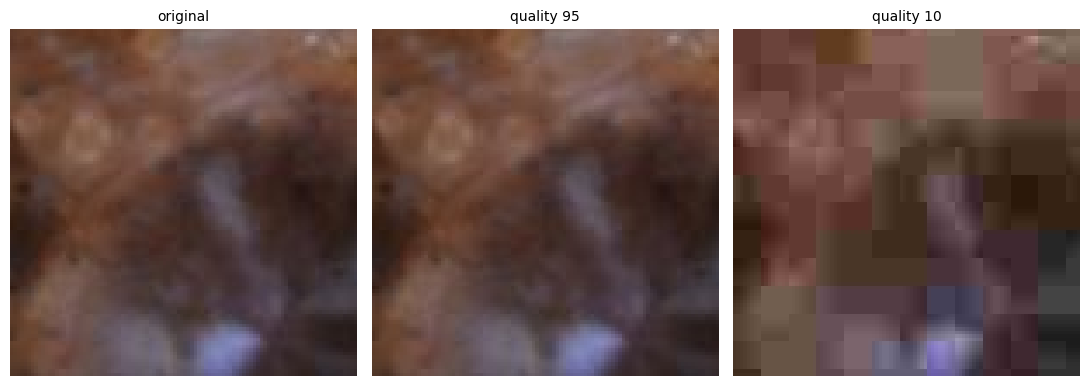

In [13]:
# zoomed crop of the best and the worst quality
crop = slice(150, 250), slice(200, 300)
fig, axes = plt.subplots(1, 3, figsize=(11, 4))
for ax, (name, im) in zip(axes, {"original": arr, "quality 95": decoded[95],
                                 "quality 10": decoded[10]}.items()):
    ax.imshow(im[crop]); ax.set_title(name, fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

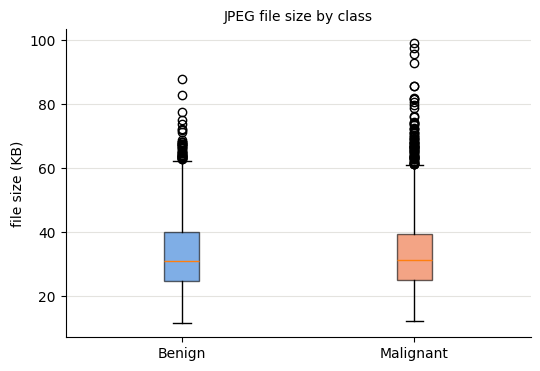

ROC-AUC of 'file size' as a malignancy score (0.5 = no signal):
  clinical: close-up   AUC = 0.505   (n = 5,117)
  dermoscopic          AUC = 0.481   (n = 5,117)


In [14]:
# (c) file size as a shortcut: no decoding needed
from sklearn.metrics import roc_auc_score

sizes = df["isic_id"].map(lambda i: os.stat(config.image_path(i)).st_size / 1024)
sized = df.assign(kb=sizes)

fig, ax = plt.subplots(figsize=(6, 4))
groups = [sized.loc[sized["diagnosis_1"] == c, "kb"] for c in ["Benign", "Malignant"]]
bp = ax.boxplot(groups, tick_labels=["Benign", "Malignant"], patch_artist=True)
for patch, c in zip(bp["boxes"], ["Benign", "Malignant"]):
    patch.set_facecolor(viz.color_of(c)); patch.set_alpha(0.6)
ax.set_ylabel("file size (KB)"); ax.set_title("JPEG file size by class", fontsize=10)
viz.style(ax); plt.show()

print("ROC-AUC of 'file size' as a malignancy score (0.5 = no signal):")
for itype, sub in sized[sized["diagnosis_1"].isin(["Benign", "Malignant"])].groupby("image_type"):
    auc = roc_auc_score(sub["diagnosis_1"].eq("Malignant"), sub["kb"])
    print(f"  {itype:20s} AUC = {auc:.3f}   (n = {len(sub):,})")

**Answer (b).** The images are already JPEG, so they carry compression artefacts
before we touch them: blocking, ringing around edges and smoothed colour detail.
Re-saving as JPEG compresses an already compressed image (double compression),
and resizing *after* compression resamples those artefacts instead of real skin
texture. Practical consequences: decode once and keep tensors, resize from the
original file rather than from a re-encoded copy, and remember that fine texture
- which is diagnostically relevant - is the first thing JPEG throws away.

**Answer (c).** If the AUC is far from 0.5, file size alone partly separates the
classes, which is a **shortcut**: file size is a property of the camera and the
compression settings, not of the lesion. Plausible causes are different devices
or clinics for different case mixes, different resolutions or noise levels (noisy,
detailed images compress worse and are bigger), and the dermatoscope's uniform
background compressing very differently from a clinical photo. Whatever the cause,
a model could learn it, so it must never be a feature - and a good test set should
not be separable by it.

## A3.1 Measure the leak

Counting leaked lesions is not enough: what does the leak do to a *metric*?
A random forest on metadata only, evaluated under a naive image-level split and
under a grouped split, 5 seeds each.

In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

FEATURES = ["age_approx", "sex", "anatom_site_general", "image_type"]

def make_model():
    """Imputation + encoding inside the Pipeline, so they are fitted on TRAIN only."""
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), ["age_approx"]),
        ("cat", Pipeline([("fill", SimpleImputer(strategy="constant", fill_value="unknown")),
                          ("oh", OneHotEncoder(handle_unknown="ignore"))]),
         ["sex", "anatom_site_general", "image_type"]),
    ])
    return Pipeline([("pre", pre),
                     ("rf", RandomForestClassifier(min_samples_leaf=1, n_estimators=200,
                                                   random_state=0))])

X, y, groups = df[FEATURES], df["diagnosis_1"], df["lesion_id"]

def naive_split(seed):
    idx = np.arange(len(df))
    return train_test_split(idx, test_size=0.2, stratify=y, random_state=seed)

def grouped_split(seed):
    sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=seed)
    return next(sgkf.split(X, y, groups))

results = {}
for name, splitter in [("naive (image-level)", naive_split), ("grouped (by lesion)", grouped_split)]:
    scores = []
    for seed in range(5):
        tr, te = splitter(seed)
        model = make_model().fit(X.iloc[tr], y.iloc[tr])
        scores.append(balanced_accuracy_score(y.iloc[te], model.predict(X.iloc[te])))
    results[name] = (np.mean(scores), np.std(scores))
    print(f"{name:22s} balanced accuracy = {np.mean(scores):.3f} +- {np.std(scores):.3f}")

naive (image-level)    balanced accuracy = 0.426 +- 0.004


grouped (by lesion)    balanced accuracy = 0.425 +- 0.010


In [16]:
# (c) sibling oracle: predict each test image with its sibling's label, if the sibling is in train
def sibling_oracle(tr, te):
    train_ids = set(df["isic_id"].iloc[tr])
    majority = y.iloc[tr].value_counts().idxmax()
    sibling_of = (df[["isic_id", "lesion_id"]].merge(df[["isic_id", "lesion_id"]], on="lesion_id")
                    .query("isic_id_x != isic_id_y")
                    .set_index("isic_id_x")["isic_id_y"])
    label_of = df.set_index("isic_id")["diagnosis_1"]

    preds, n_with_sibling = [], 0
    for iid in df["isic_id"].iloc[te]:
        sib = sibling_of.get(iid)
        if sib is not None and sib in train_ids:
            preds.append(label_of[sib]); n_with_sibling += 1
        else:
            preds.append(majority)
    return (balanced_accuracy_score(y.iloc[te], preds), n_with_sibling / len(te))

for name, splitter in [("naive (image-level)", naive_split), ("grouped (by lesion)", grouped_split)]:
    tr, te = splitter(0)
    acc, share = sibling_oracle(tr, te)
    print(f"{name:22s} oracle balanced accuracy = {acc:.3f}   "
          f"test images whose sibling is in train: {share:.1%}")

naive (image-level)    oracle balanced accuracy = 0.858   test images whose sibling is in train: 79.4%


grouped (by lesion)    oracle balanced accuracy = 0.333   test images whose sibling is in train: 0.0%


**Answer (d).** Compare the two balanced accuracies above. This random forest
only sees age, sex, site and image type - and those four values are *identical*
for the two photos of a lesion. So having a sibling in train teaches it nothing
that any other patient of the same age and site would not teach it, and the leak
moves the metric very little (any difference here is mostly split-to-split noise,
which the +- shows).

The sibling oracle is what exposes the real danger. Under the naive split most
test images have their sibling in train, and just copying the sibling's label
scores far above the honest baseline; under the grouped split no sibling is ever
available and the oracle collapses to chance. That gap is the score a model which
can **recognise the lesion** - a CNN looking at two photos of the same mole, or at
near-duplicate shots - could reach without learning any pathology.

So "I did not measure any inflation" is not a reason to skip the grouped split.
It only means that today's weak, metadata-only model cannot exploit the leak. The
leak is still in the data, and the stronger the model gets at recognising images,
the more of that oracle score it can steal.

## A3.2 A reusable three-way split

In [17]:
from src.splits import split_lesions, check_splits

train_ids, val_ids, test_ids = split_lesions(lesions, val_size=0.15, test_size=0.15,
                                             seed=config.SEED)
print({k: f"{v:.1%}" for k, v in check_splits(train_ids, val_ids, test_ids, lesions).items()})

# property test over 10 seeds
rare = ["MAL_OTH", "DF", "INF", "VASC", "BEN_OTH"]
present = {c: 0 for c in rare}
for seed in range(10):
    tr, va, te = split_lesions(lesions, seed=seed)
    check_splits(tr, va, te, lesions)                      # no overlap + sizes within 1 pp
    assert (tr, va, te) == split_lesions(lesions, seed=seed)   # same seed -> same output
    in_val = set(lesions[lesions["lesion_id"].isin(va)]["dx"])
    in_test = set(lesions[lesions["lesion_id"].isin(te)]["dx"])
    for c in rare:
        present[c] += int(c in in_val and c in in_test)
print("\n10 seeds passed: no overlap, sizes within 1 pp, reproducible")
print("\nrare class present in BOTH val and test (out of 10 seeds):")
print(pd.Series(present).to_string())

{'train': '70.0%', 'val': '15.0%', 'test': '15.0%'}



10 seeds passed: no overlap, sizes within 1 pp, reproducible

rare class present in BOTH val and test (out of 10 seeds):
MAL_OTH     5
DF         10
INF        10
VASC       10
BEN_OTH    10


**What that means for evaluating the rarest classes.** The rarest classes are
often absent from val or test - with only a handful of lesions in the whole
dataset, a 15 % slice frequently contains none of them. So a per-class score for
those classes is unstable or undefined: it is computed on a couple of lesions, or
not at all. Anything I claim about them must come from cross-validation over all
folds rather than from one test split, and macro-averaged metrics have to be read
knowing that those classes barely contribute.

## A3.3 Why StratifiedGroupKFold?

In [18]:
from src.splits import compare_fold_strategies

comparison = compare_fold_strategies(lesions, df, rare_class="MAL_OTH")
display(comparison)

,strategy,leaked_lesions,max_class_spread_pp,folds_without_MAL_OTH
0,GroupKFold (groups only),0,3.05,0
1,"StratifiedKFold (images, no groups)",8500,0.05,0
2,StratifiedGroupKFold (both),0,3.82,1


**Conclusion.** GroupKFold never leaks but lets the class mix drift between folds,
because nothing keeps the rare classes balanced. StratifiedKFold on images keeps
the mix even but splits lesions across folds - straight leakage.
**StratifiedGroupKFold** is the only one that does both, so it is what the project
uses; the price is that the rarest class can still be missing from a fold, which
no strategy can fix when the class has fewer lesions than there are folds.

## A3.4 Metrics and the cost of errors

In [19]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, confusion_matrix,
                             f1_score)

test_lesions = lesions[lesions["lesion_id"].isin(test_ids)]
train_lesions = lesions[lesions["lesion_id"].isin(train_ids)]
y_tr, y_te = train_lesions["diagnosis_1"], test_lesions["diagnosis_1"]
X_tr, X_te = np.zeros((len(y_tr), 1)), np.zeros((len(y_te), 1))   # dummies ignore X

dummies = {
    "always Malignant": DummyClassifier(strategy="constant", constant="Malignant"),
    "stratified random": DummyClassifier(strategy="stratified", random_state=0),
    "uniform random": DummyClassifier(strategy="uniform", random_state=0),
}
preds, rows = {}, []
for name, clf in dummies.items():
    clf.fit(X_tr, y_tr)
    p = clf.predict(X_te)
    preds[name] = p
    rows.append({"predictor": name,
                 "accuracy": round(accuracy_score(y_te, p), 3),
                 "balanced accuracy": round(balanced_accuracy_score(y_te, p), 3),
                 "macro-F1": round(f1_score(y_te, p, average="macro", zero_division=0), 3)})
display(pd.DataFrame(rows))

classes = sorted(y_te.unique())
cm = confusion_matrix(y_te, preds["stratified random"], labels=classes)
print("confusion matrix - stratified random (rows = truth, columns = prediction):")
display(pd.DataFrame(cm, index=classes, columns=classes))

,predictor,accuracy,balanced accuracy,macro-F1
0,always Malignant,0.717,0.333,0.278
1,stratified random,0.582,0.350,0.350
2,uniform random,0.352,0.379,0.284


confusion matrix - stratified random (rows = truth, columns = prediction):


,Benign,Indeterminate,Malignant
Benign,59,6,141
Indeterminate,6,1,10
Malignant,155,11,398


In [20]:
# (b) an explicit cost matrix: what each mistake costs
COSTS = {("Malignant", "Benign"): 50, ("Malignant", "Indeterminate"): 25,
         ("Benign", "Malignant"): 1, ("Benign", "Indeterminate"): 1,
         ("Indeterminate", "Benign"): 5, ("Indeterminate", "Malignant"): 5}

def expected_cost(truth, pred):
    return float(np.mean([COSTS.get((t, p), 0) for t, p in zip(truth, pred)]))

always_benign = np.full(len(y_te), "Benign")
costs = {name: expected_cost(y_te, p) for name, p in preds.items()}
costs["always Benign"] = expected_cost(y_te, always_benign)
cost_table = (pd.Series(costs).rename("cost per lesion").to_frame().round(2)
                .sort_values("cost per lesion"))
display(cost_table)
print("cheapest under these costs:", cost_table.index[0])

,cost per lesion
always Malignant,0.37
stratified random,10.49
uniform random,17.85
always Benign,35.94


cheapest under these costs: always Malignant


**Answer (c).** Under this cost matrix the cheapest constant prediction is
**always Malignant**: it never misses a cancer, and the price is one unnecessary
work-up per benign lesion. The ranking by cost is *not* the ranking by accuracy -
a predictor can look better on accuracy while being much more expensive, because
accuracy treats a missed melanoma and an unnecessary biopsy as the same mistake.
This is also why "always Malignant" must not be read as a good model: it is only
cheap because MILK10k is biopsy-enriched, and in a real clinic, where most lesions
are benign, the same rule would send everyone to surgery.

## A3.5 Is this augmentation label-safe?

Compare the colour gap *between the classes* with the colour change an
augmentation introduces. If the augmentation moves colour more than the disease
does, it can erase the signal.

In [21]:
import torch
import torchvision.transforms as T

def hsv_stats(isic_id, img=None):
    """
    Mean hue (degrees, circular) and mean brightness V of the darker lesion pixels.
    draft_size=160 decodes the JPEG small immediately: these are averages over many
    pixels, so a smaller decode gives the same answer several times faster.
    """
    img = img if img is not None else _load_rgb(isic_id, draft_size=160)
    hsv = np.array(img.convert("HSV"), dtype=np.float32)
    h, s, v = hsv[..., 0] * 360 / 255, hsv[..., 1], hsv[..., 2]
    mask = v < np.percentile(v, 40)          # the lesion is darker than the skin around it
    ang = np.deg2rad(h[mask])
    hue = float((np.rad2deg(np.arctan2(np.sin(ang).mean(), np.cos(ang).mean()))) % 360)
    return hue, float(v[mask].mean())

n_per_group = 100
sample = (lesions.groupby("diagnosis_1").head(n_per_group)
                 .query("diagnosis_1 in ['Benign', 'Malignant']"))
stats = pd.DataFrame([dict(diagnosis_1=r.diagnosis_1, **dict(zip(["hue", "V"], hsv_stats(r.derm_id))))
                      for r in sample.itertuples()])
group_means = stats.groupby("diagnosis_1")[["hue", "V"]].mean()
display(group_means.round(2))

hue_gap = abs(group_means.loc["Benign", "hue"] - group_means.loc["Malignant", "hue"])
v_gap = abs(group_means.loc["Benign", "V"] - group_means.loc["Malignant", "V"])
print(f"class gap: hue {hue_gap:.1f} degrees | brightness {v_gap:.1f} (0-255)")

,hue,V
diagnosis_1,,
Benign,118.32,147.02
Malignant,126.44,155.25


class gap: hue 8.1 degrees | brightness 8.2 (0-255)


In [22]:
# how much does ColorJitter move the same numbers?
torch.manual_seed(0)
probe = [r.derm_id for r in sample.head(20).itertuples()]
rows = []
for hue in [0.02, 0.05, 0.1, 0.5]:
    jit = T.ColorJitter(hue=hue)
    shifts = []
    for iid in probe:
        im = _load_rgb(iid, draft_size=160)      # decode once, reuse for both measurements
        before, _ = hsv_stats(iid, img=im)
        after_img = jit(im)
        hsv = np.array(after_img.convert("HSV"), dtype=np.float32)
        v = hsv[..., 2]; mask = v < np.percentile(v, 40)
        ang = np.deg2rad(hsv[..., 0][mask] * 360 / 255)
        after = float(np.rad2deg(np.arctan2(np.sin(ang).mean(), np.cos(ang).mean())) % 360)
        shifts.append(min(abs(after - before), 360 - abs(after - before)))
    rows.append({"parameter": f"hue={hue}", "max possible shift (deg)": hue * 360,
                 "measured mean shift (deg)": round(np.mean(shifts), 1),
                 "bigger than the class gap?": np.mean(shifts) > hue_gap})
for bright in [0.1, 0.3, 0.6]:
    jit = T.ColorJitter(brightness=bright)
    shifts = []
    for iid in probe:
        im = _load_rgb(iid, draft_size=160)
        _, before = hsv_stats(iid, img=im)
        hsv = np.array(jit(im).convert("HSV"), dtype=np.float32)
        v = hsv[..., 2]; mask = v < np.percentile(v, 40)
        shifts.append(abs(float(v[mask].mean()) - before))
    rows.append({"parameter": f"brightness={bright}", "max possible shift (deg)": np.nan,
                 "measured mean shift (deg)": round(np.mean(shifts), 1),
                 "bigger than the class gap?": np.mean(shifts) > v_gap})
display(pd.DataFrame(rows))

,parameter,max possible shift (deg),measured mean shift (deg),bigger than the class gap?
0,hue=0.02,7.2,3.6,False
1,hue=0.05,18.0,8.7,True
2,hue=0.1,36.0,16.5,True
3,hue=0.5,180.0,76.3,True
4,brightness=0.1,NaN,9.1,True
5,brightness=0.3,NaN,27.4,True
6,brightness=0.6,NaN,31.0,True


**Answer (b).** Read the table above: any row where the measured shift is bigger
than the class gap is an augmentation that changes colour more than the disease
does, and is therefore unsafe.

Geometric augmentations are **safe**: flips, rotations and small crops (scale
>= 0.85, so the lesion is never cropped out) change where the lesion sits, not what
it looks like. Mild brightness and contrast jitter is **acceptable**, because
lighting genuinely varies between clinics - but only at the settings whose shift
stays below the class gap; the larger values in the table do not. **Hue jitter is
the risky one**: redness and pigmentation are the diagnostic signal, so even a
modest hue shift moves colour in the same direction the disease does, and
hue = 0.5 turns skin green or blue, which is no longer a plausible lesion at all.
That is why the project's `train_transform` uses `hue=0` and keeps brightness and
contrast at 0.2.

Who must approve them: a clinician. "Does this still show the same diagnosis?" is
a medical question, not an engineering one.

## A3.6 A lesion-level Dataset

In [23]:
from torch.utils.data import DataLoader
from src.datasets import LesionDataset, aggregate_predictions
from src.labels import build_label_map
from src.transforms import eval_transform

label_map = build_label_map(lesions["dx"], "dx")["classes"]
ds = LesionDataset(lesions, label_map, label_col="dx", transform=eval_transform(),
                   views=("derm", "clinical"))
loader = DataLoader(ds, batch_size=8, shuffle=False)

batch = next(iter(loader))
print("(a) derm:", tuple(batch["derm"].shape), "| clinical:", tuple(batch["clinical"].shape))
expected = [label_map[d] for d in lesions["dx"].head(8)]
assert batch["label"].tolist() == expected
assert list(batch["lesion_id"]) == lesions["lesion_id"].head(8).tolist()
print("    lesion_ids and labels match the table:", True)

(a) derm: (8, 3, 224, 224) | clinical: (8, 3, 224, 224)
    lesion_ids and labels match the table: True


In [24]:
# (b) one epoch over a subset: the classes seen must equal the classes in the subset
# This check only counts labels, so it does not need full-size images: decode the
# JPEGs small (draft_size), build 64x64 tensors and read one view. Same result,
# a fraction of the time - (a) already verified the real shapes at 224x224.
subset = lesions.head(min(800, len(lesions)))
sub_loader = DataLoader(
    LesionDataset(subset, label_map, "dx", eval_transform(64),
                  views=("derm",), draft_size=128),
    batch_size=16, shuffle=True)
seen = []
for b in sub_loader:
    seen += b["label"].tolist()
inv = {v: k for k, v in label_map.items()}
seen_counts = pd.Series([inv[i] for i in seen]).value_counts().sort_index()
true_counts = subset["dx"].value_counts().sort_index()
assert seen_counts.equals(true_counts)
print("(b) class counts seen in one epoch match the subset:", True)
print(seen_counts.to_string())

(b) class counts seen in one epoch match the subset: True
AKIEC       45
BCC        366
BEN_OTH      9
BKL         88
DF           9
INF          6
MAL_OTH      1
MEL         81
NV         120
SCCKA       69
VASC         6


In [25]:
# (c) image-level probabilities -> one prediction per lesion
rng = np.random.default_rng(0)
img_table = df[["isic_id", "lesion_id"]].head(6)
classes = ["Benign", "Indeterminate", "Malignant"]
probs = pd.DataFrame(rng.dirichlet(np.ones(3), size=len(img_table)),
                     index=img_table["isic_id"], columns=classes)
display(probs.round(3))
print("(c) aggregated per lesion (mean of the two views):")
display(aggregate_predictions(probs, img_table).round(3))

,Benign,Indeterminate,Malignant
isic_id,,,
ISIC_0051817,0.395,0.593,0.012
ISIC_0073863,0.001,0.252,0.747
ISIC_0075884,0.159,0.178,0.663
ISIC_0076255,0.648,0.352,0.000
ISIC_0077054,0.665,0.021,0.314
ISIC_0078190,0.195,0.724,0.081


(c) aggregated per lesion (mean of the two views):


,Benign,Indeterminate,Malignant,prediction
lesion_id,,,,
IL_1612768,0.395,0.593,0.012,Indeterminate
IL_2547802,0.001,0.252,0.747,Malignant
IL_4115404,0.195,0.724,0.081,Indeterminate
IL_5271098,0.665,0.021,0.314,Benign
IL_8089688,0.648,0.352,0.000,Benign
IL_9270970,0.159,0.178,0.663,Malignant


**Answer (d).** The correct unit of evaluation is the **lesion**, because that is
what a doctor decides about: one lesion, one decision. If you evaluate per image,
every lesion is counted twice, and the two photos are not independent - so the
test set effectively has half as many independent cases as it appears to, and the
confidence in the score is overstated. Worse, a model can be right on the
dermoscopic view and wrong on the clinical one, which per-image scoring reports as
"half right" instead of forcing the pipeline to commit to a single answer per
lesion.